# Field Line Tracing with the geopack Engine (scalar vs vectorized)

> **Which tracer should I use?** For analysis work use the top-level `mageometry.trace_field_lines(field, x, y, z, ...)`: it traces any field callable (Tsyganenko models via `geopack_field`, simulation data via `GriddedField.field()`), traces both directions at once, returns arc length along the path, and its output feeds directly into the geometry functions — see section 9 at the end of this notebook and notebook 07. `geopack.trace` / `geopack.trace_vectorized` covered here are the field engine's bitwise-faithful port of the original scalar `geopack.trace()`, kept as the validation reference for the engine.

Field Line Tracing in Geopack (trace: Scalar + Vectorized)


This notebook covers `geopack.trace()` (scalar version) and `geopack.trace_vectorized()` (vectorized version)

as a practical guide for field line tracing.


---


Key idea: What is field line tracing?


A field line is a curve tangent to the magnetic field vector **B**. trace numerically integrates from an initial point to produce a sequence of points satisfying:


- Advancing **parallel to B** (dir=-1) or **anti-parallel to B** (dir=+1)

- Until reaching Earth's surface (r0) or truncating at the outer boundary (rlim, etc.)


---


Important: Always call recalc() first


`trace` internally references values needed for IGRF coefficients and coordinate transformations (psi, etc.).

Therefore, **you must call `geopack.recalc(ut)` before trace**.


---


Implementation notes (stopping conditions)


Following the scalar version code, the loop stops under these conditions:


- Outer boundary:

  - r >= rlim  or

  - y^2+z^2 >= 1600 (= 40 Re cylinder) or

  - x >= 20

- Inner boundary:

  - When r < r0 is crossed from outside (footpoint found by interpolation)

- When maxloop is reached


The vectorized version returns status codes (examples):

- 0 = Reached inner boundary (r0)

- 1 = Stopped at outer boundary

- 2 = Exceeded maxloop


---


Supported models (exname / inname)


- External field (Tsyganenko): `exname = "t89" | "t96" | "t01" | "t04"`

- Internal field: `inname = "igrf"` (assumes IGRF_GSM) or `inname = "dip"`


Note: For exname="t89", parmod is iopt (Kp level).

Note: For exname="t96/t01/t04", parmod is a 10-element array (Pdyn, Dst, By, Bz, ...).


---


Outline of this notebook

1. Setup

2. trace arguments and return values (overview)

3. Helpers (parameter generation / return value normalization)

4. geopack initialization (recalc)

5. Scalar version: single-point trace (footpoint + path)

6. Vectorized version: batch trace of multiple points (endpoint + path)

7. Visualization (X-Z plane projection)

8. Performance comparison (scalar vs vectorized)

9. Generic tracing with `mageometry.trace_field_lines`


## 1) Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from datetime import datetime
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

from mageometry import geopack
from mageometry.geopack import recalc  # Important: always call before trace

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

print("Environment")
import sys
print("  python:", sys.version.split()[0])
print("  numpy :", np.__version__)


Load IGRF coefficients ...


Environment
  python: 3.12.3
  numpy : 2.5.2


### Notebook-wide knobs

In [2]:
# --- tracing knobs ---
TRACE_R0   = 1.0     # Inner boundary (Earth's surface) [Re]
TRACE_RLIM = 15.0    # Outer boundary [Re]
TRACE_MAXLOOP = 2000 # Maximum number of steps

# --- model selection ---
DEFAULT_EXNAME = "t96"   # "t89" | "t96" | "t01" | "t04"
DEFAULT_INNAME = "igrf"  # "igrf" | "dip"

# --- vectorized trace behavior ---
# strict_scalar_models=True: Evaluate external/internal models point-by-point for consistency
# strict_scalar_models=False: Use vectorized models for speed (may produce small differences)
VEC_STRICT_SCALAR_MODELS = True

# --- visualization ---
PLOT_EARTH = True


2) trace arguments and return values (overview)


Scalar: `geopack.trace(xi, yi, zi, dir, rlim=..., r0=..., parmod=..., exname=..., inname=..., maxloop=...)`

- Input is in **GSM coordinates** (Re)

- `dir=+1`: Advance anti-parallel to B (e.g., toward the north-to-south conjugate point)

- `dir=-1`: Advance parallel to B

- `parmod`:

  - T89: iopt (1..7)

  - T96/T01/T04: 10-element array

- Return values (scalar implementation):

  - `xf, yf, zf, xx, yy, zz`

    - xx/yy/zz are path point sequences (variable length)


Vectorized: `geopack.trace_vectorized(...)`

- xi,yi,zi are scalar or 1D array

- Return values (implementation-dependent):

  - Minimum: `xf, yf, zf, status`

  - If `return_full_path=True`: also returns `xx, yy, zz` (masked array)

  - If `return_nsteps=True`: also returns `nsteps` (accepted step count)


Note: Since the return value tuple structure may vary depending on the package,

  this notebook provides helpers to normalize the return values.

## 3) Helpers (parmod generation / return value normalization / visualization)

In [3]:
def make_parmod_t89(iopt: int = 4) -> int:
    """For T89: parmod=iopt (1..7)"""
    return int(iopt)

def make_parmod_t96(Pdyn=3.0, Dst=-50.0, By=0.0, Bz=-5.0) -> np.ndarray:
    """For T96: parmod[0]=Pdyn, [1]=Dst, [2]=ByIMF, [3]=BzIMF, rest=0"""
    p = np.zeros(10, dtype=np.float64)
    p[0] = Pdyn
    p[1] = Dst
    p[2] = By
    p[3] = Bz
    return p

def make_parmod_t01(Pdyn=3.0, Dst=-50.0, By=0.0, Bz=-5.0, G1=2.0, G2=3.0) -> np.ndarray:
    """For T01: T96+G1,G2"""
    p = make_parmod_t96(Pdyn, Dst, By, Bz)
    p[4] = G1
    p[5] = G2
    return p

def make_parmod_t04(Pdyn=3.0, Dst=-50.0, By=0.0, Bz=-5.0, W=None) -> np.ndarray:
    """For T04: T96+W1..W6"""
    p = make_parmod_t96(Pdyn, Dst, By, Bz)
    if W is None:
        W = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
    p[4:10] = np.asarray(W, dtype=np.float64)
    return p

def pretty_parmod(exname: str, parmod) -> str:
    ex = exname.lower()
    if ex == "t89":
        return f"T89 iopt={int(parmod)}"
    p = np.asarray(parmod, dtype=np.float64)
    base = f"Pdyn={p[0]:.2f} nPa, Dst={p[1]:.1f} nT, By={p[2]:.2f} nT, Bz={p[3]:.2f} nT"
    if ex == "t96":
        return f"T96: {base}"
    if ex == "t01":
        return f"T01: {base}, G1={p[4]:.2f}, G2={p[5]:.2f}"
    if ex == "t04":
        w = ", ".join([f"{v:.2f}" for v in p[4:10]])
        return f"T04: {base}, W=[{w}]"
    return base

def norm3(x, y, z):
    return np.sqrt(x*x + y*y + z*z)

def trace_scalar_normalized(
    xi, yi, zi,
    dir=1.0,
    rlim=TRACE_RLIM,
    r0=TRACE_R0,
    parmod=2,
    exname="t89",
    inname="igrf",
    maxloop=TRACE_MAXLOOP,
):
    """
    Call geopack.trace (scalar version) and normalize the return values.
    Expected return values: xf,yf,zf,xx,yy,zz
    """
    out = geopack.trace(xi, yi, zi, dir, rlim=rlim, r0=r0, parmod=parmod, exname=exname, inname=inname, maxloop=maxloop)

    # Safeguard against implementation differences (interpret based on tuple length)
    if isinstance(out, tuple):
        if len(out) == 6:
            xf, yf, zf, xx, yy, zz = out
            status = None
            return float(xf), float(yf), float(zf), np.asarray(xx), np.asarray(yy), np.asarray(zz), status
        elif len(out) == 7:
            xf, yf, zf, xx, yy, zz, status = out
            return float(xf), float(yf), float(zf), np.asarray(xx), np.asarray(yy), np.asarray(zz), int(status)
        else:
            raise RuntimeError(f"Unexpected scalar trace return length: {len(out)}")
    raise RuntimeError("Unexpected scalar trace return type")

def trace_vectorized_normalized(
    xi, yi, zi,
    dir=1.0,
    rlim=TRACE_RLIM,
    r0=TRACE_R0,
    parmod=2,
    exname="t89",
    inname="igrf",
    maxloop=TRACE_MAXLOOP,
    return_full_path=True,
    strict_scalar_models=VEC_STRICT_SCALAR_MODELS,
    return_nsteps=True,
):
    """
    Call geopack.trace_vectorized (vectorized version) and normalize the return values.
    """
    out = geopack.trace_vectorized(
        xi, yi, zi,
        dir=dir,
        rlim=rlim,
        r0=r0,
        parmod=parmod,
        exname=exname,
        inname=inname,
        maxloop=maxloop,
        return_full_path=return_full_path,
        strict_scalar_models=strict_scalar_models,
        return_nsteps=return_nsteps,
    )

    # Expected structure (return_full_path=True, return_nsteps=True):
    # xf, yf, zf, xx, yy, zz, status, nsteps
    if not isinstance(out, tuple):
        raise RuntimeError("Unexpected vectorized trace return type")

    if return_full_path and return_nsteps and len(out) == 8:
        xf, yf, zf, xx, yy, zz, status, nsteps = out
        return xf, yf, zf, xx, yy, zz, status, nsteps

    if return_full_path and (not return_nsteps) and len(out) == 7:
        xf, yf, zf, xx, yy, zz, status = out
        return xf, yf, zf, xx, yy, zz, status, None

    if (not return_full_path) and return_nsteps and len(out) == 5:
        xf, yf, zf, status, nsteps = out
        return xf, yf, zf, None, None, None, status, nsteps

    if (not return_full_path) and (not return_nsteps) and len(out) == 4:
        xf, yf, zf, status = out
        return xf, yf, zf, None, None, None, status, None

    raise RuntimeError(f"Unexpected vectorized trace return length: {len(out)}")

def plot_field_lines_xz(lines, title="", earth_radius=1.0):
    """
    lines: list of dict
      - {"xx":..., "yy":..., "zz":..., "label":..., "style":...}
    Project onto X-Z plane for plotting (Y is ignored)
    """
    plt.figure(figsize=(10, 7))
    for ln in lines:
        xx = ln["xx"]; zz = ln["zz"]
        label = ln.get("label", "")
        style = ln.get("style", "-")
        plt.plot(xx, zz, style, lw=2, label=label)

    if PLOT_EARTH:
        th = np.linspace(0, 2*np.pi, 400)
        plt.plot(earth_radius*np.cos(th), earth_radius*np.sin(th), "k", lw=2)

    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("X GSM [Re]")
    plt.ylabel("Z GSM [Re]")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    if any(ln.get("label") for ln in lines):
        plt.legend()
    plt.show()


## 4) geopack initialization (recalc)


Always execute before trace (updates IGRF coefficients, tilt, etc.).

In [4]:
ut = datetime(2015, 3, 17, 12, 0, 0).timestamp()
ps = recalc(ut)

print(f"Time UTC: {datetime.utcfromtimestamp(ut)}")
print(f"Dipole tilt ps: {ps:.6f} rad = {np.degrees(ps):.2f} deg")


Time UTC: 2015-03-17 03:00:00
Dipole tilt ps: -0.172710 rad = -9.90 deg


/tmp/ipykernel_165717/80392931.py:4: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  print(f"Time UTC: {datetime.utcfromtimestamp(ut)}")


## 5) Scalar version: single-point trace (footpoint + path)


- Place the initial point (xi,yi,zi) **outside r0** (r<=r0 may fail to start or be unstable)

- Changing dir reaches the footpoint in the opposite direction


Here as an example:

- exname = T96

- inname = IGRF

- r0 = 1.0, rlim = 15.0

Start (GSM): (-6.0, 2.0, 3.0)  r= 7.0
Model: T96: Pdyn=4.00 nPa, Dst=-75.0 nT, By=5.00 nT, Bz=-8.00 nT | internal: igrf

[Scalar trace results]
  dir=+1 endpoint: (-14.247418183924765, 3.965406385314801, 3.402147346478779)  r= 15.175242313567121  status= None
  dir=-1 endpoint: (-0.4536424805019074, 0.16282716196207342, 0.8745972285077431)  r= 0.998611284185179  status= None
  path lengths: 18 21


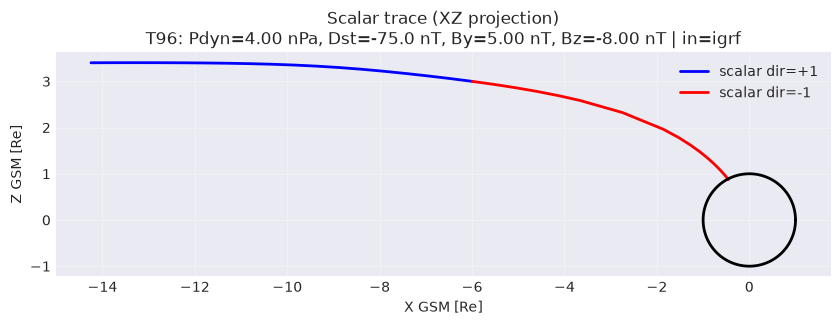

In [5]:
# Initial point (GSM, Re)
xi, yi, zi = -6.0, 2.0, 3.0
print("Start (GSM):", (xi, yi, zi), " r=", float(norm3(xi, yi, zi)))

exname = DEFAULT_EXNAME
inname = DEFAULT_INNAME
parmod = make_parmod_t96(Pdyn=4.0, Dst=-75.0, By=5.0, Bz=-8.0)

print("Model:", pretty_parmod(exname, parmod), "| internal:", inname)

# Trace with dir=+1 (anti-parallel)
xf1, yf1, zf1, xx1, yy1, zz1, st1 = trace_scalar_normalized(
    xi, yi, zi,
    dir=+1.0,
    rlim=TRACE_RLIM,
    r0=TRACE_R0,
    parmod=parmod,
    exname=exname,
    inname=inname,
    maxloop=TRACE_MAXLOOP,
)

# Trace with dir=-1 (parallel)
xf2, yf2, zf2, xx2, yy2, zz2, st2 = trace_scalar_normalized(
    xi, yi, zi,
    dir=-1.0,
    rlim=TRACE_RLIM,
    r0=TRACE_R0,
    parmod=parmod,
    exname=exname,
    inname=inname,
    maxloop=TRACE_MAXLOOP,
)

print("\n[Scalar trace results]")
print("  dir=+1 endpoint:", (xf1, yf1, zf1), " r=", float(norm3(xf1, yf1, zf1)), " status=", st1)
print("  dir=-1 endpoint:", (xf2, yf2, zf2), " r=", float(norm3(xf2, yf2, zf2)), " status=", st2)
print("  path lengths:", len(xx1), len(xx2))

# Visualization (X-Z projection)
plot_field_lines_xz(
    lines=[
        {"xx": xx1, "zz": zz1, "label": "scalar dir=+1", "style": "b-"},
        {"xx": xx2, "zz": zz2, "label": "scalar dir=-1", "style": "r-"},
    ],
    title=f"Scalar trace (XZ projection)\n{pretty_parmod(exname, parmod)} | in={inname}",
)


### Supplement: How to obtain conjugate footpoints


By running dir=+1 and dir=-1 from the same initial point,

you can obtain something like "footpoints in both directions (north/south) on the same field line"

(depends on the magnetic field model).

## 6) Vectorized version: batch trace of multiple points (endpoint + path)


`geopack.trace_vectorized()` can process arrays of initial points together.


- `return_full_path=True` returns a (n_traces, maxloop+1) masked array

- `strict_scalar_models=True` aims for scalar-like behavior (slow)

- `strict_scalar_models=False` aims for speedup (may produce small differences)

N starts: 12
r(min/max): 6.049078989016822 8.43320919302449



[Vectorized trace results]
  elapsed: 1.080s | strict_scalar_models = True
  status counts: {np.int32(0): np.int64(7), np.int32(1): np.int64(5)}
  nsteps(min/mean/max): 14 23.25 60

Example line[0] points: 26  endpoint: (-0.04047628223434897, 0.027288869002909194, -0.9930304543130909)


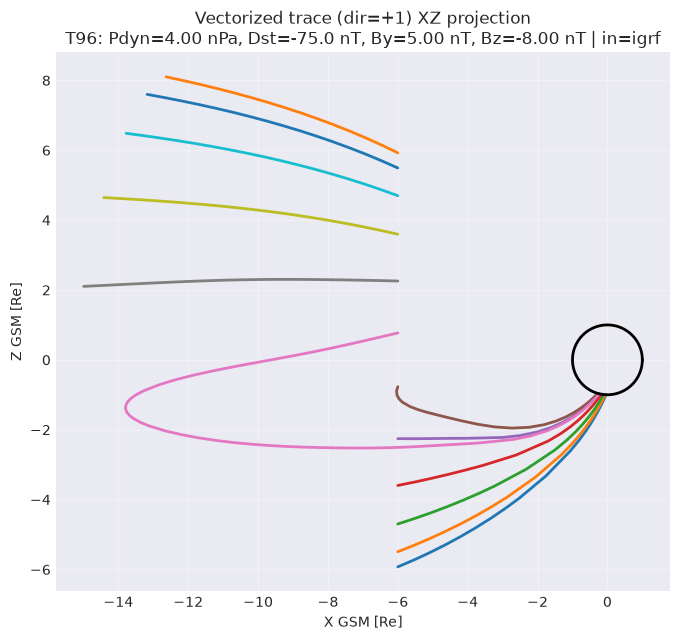

In [6]:
# Create multiple initial points (e.g., on an arc in the X-Z plane)
n0 = 12
theta = np.linspace(-0.9*np.pi/2, 0.9*np.pi/2, n0)  # -81deg..+81deg
r_start = 6.0
xi_arr = -r_start * np.ones_like(theta)
yi_arr = np.zeros_like(theta)
zi_arr = r_start * np.sin(theta)

print("N starts:", xi_arr.size)
print("r(min/max):", float(np.min(norm3(xi_arr, yi_arr, zi_arr))), float(np.max(norm3(xi_arr, yi_arr, zi_arr))))

t0 = time.time()
xf, yf, zf, xx, yy, zz, status, nsteps = trace_vectorized_normalized(
    xi_arr, yi_arr, zi_arr,
    dir=+1.0,
    rlim=TRACE_RLIM,
    r0=TRACE_R0,
    parmod=parmod,
    exname=exname,
    inname=inname,
    maxloop=TRACE_MAXLOOP,
    return_full_path=True,
    strict_scalar_models=VEC_STRICT_SCALAR_MODELS,
    return_nsteps=True,
)
t1 = time.time()

print("\n[Vectorized trace results]")
print("  elapsed:", f"{t1-t0:.3f}s", "| strict_scalar_models =", VEC_STRICT_SCALAR_MODELS)
print("  status counts:", dict(zip(*np.unique(status, return_counts=True))))
if nsteps is not None:
    print("  nsteps(min/mean/max):", int(np.min(nsteps)), float(np.mean(nsteps)), int(np.max(nsteps)))

# Example: extract and display a single path (masked -> valid points only)
k = 0
valid = ~xx.mask[k]
xxk = xx.data[k][valid]
zzk = zz.data[k][valid]
print("\nExample line[0] points:", xxk.size, " endpoint:", (float(xf[k]), float(yf[k]), float(zf[k])))

# Display all lines in X-Z projection
lines = []
for i in range(n0):
    v = ~xx.mask[i]
    lines.append({"xx": xx.data[i][v], "zz": zz.data[i][v], "label": None, "style": "-"})

plot_field_lines_xz(
    lines=lines,
    title=f"Vectorized trace (dir=+1) XZ projection\n{pretty_parmod(exname, parmod)} | in={inname}",
)


## 7) Scalar vs vectorized comparison (path shape from the same initial point)


When the vectorized version uses `strict_scalar_models=True`, it evaluates the model point-by-point,

aiming for results close to the scalar version (though exact match is not guaranteed due to environment and implementation differences).


Here we compare the same initial point with scalar and vectorized, both with dir=+1.

[Compare endpoints]
  scalar endpoint: (-14.908020795409726, 2.6721727642587205, 2.422187472148964)  status= None  npts= 17
  vector endpoint : (-14.908020795409726, 2.6721727642587205, 2.422187472148964)  status= 1  npts= 17


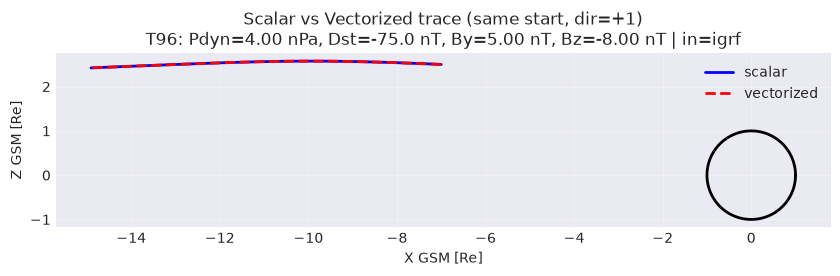

In [7]:
# Single point for comparison
xi0, yi0, zi0 = -7.0, 1.5, 2.5

# scalar
xf_s, yf_s, zf_s, xx_s, yy_s, zz_s, st_s = trace_scalar_normalized(
    xi0, yi0, zi0,
    dir=+1.0,
    rlim=TRACE_RLIM,
    r0=TRACE_R0,
    parmod=parmod,
    exname=exname,
    inname=inname,
    maxloop=TRACE_MAXLOOP,
)

# vectorized (works with a single point too)
xf_v, yf_v, zf_v, xx_v, yy_v, zz_v, st_v, ns_v = trace_vectorized_normalized(
    xi0, yi0, zi0,
    dir=+1.0,
    rlim=TRACE_RLIM,
    r0=TRACE_R0,
    parmod=parmod,
    exname=exname,
    inname=inname,
    maxloop=TRACE_MAXLOOP,
    return_full_path=True,
    strict_scalar_models=True,  # Prioritize consistency for comparison
    return_nsteps=True,
)

# vectorized single point may be trimmed to 1D arrays as scalar output in some implementations, absorb type
if hasattr(xx_v, "mask"):
    vv = ~xx_v.mask
    xx_v1 = xx_v.data[vv]
    zz_v1 = zz_v.data[vv]
else:
    xx_v1 = np.asarray(xx_v)
    zz_v1 = np.asarray(zz_v)

print("[Compare endpoints]")
print("  scalar endpoint:", (xf_s, yf_s, zf_s), " status=", st_s, " npts=", len(xx_s))
print("  vector endpoint :", (float(xf_v), float(yf_v), float(zf_v)), " status=", int(st_v), " npts=", len(xx_v1))

plot_field_lines_xz(
    lines=[
        {"xx": xx_s,  "zz": zz_s,  "label": "scalar",    "style": "b-"},
        {"xx": xx_v1, "zz": zz_v1, "label": "vectorized","style": "r--"},
    ],
    title=f"Scalar vs Vectorized trace (same start, dir=+1)\n{pretty_parmod(exname, parmod)} | in={inname}",
)


## 8) Performance comparison (scalar vs vectorized)


- scalar: trace one point at a time (Python loop, N times)

- vectorized: trace N points together


Note:

- vectorized with `strict_scalar_models=True` is slower (evaluates the model point-by-point).

- For speed, try `strict_scalar_models=False` (may produce small differences in results).

,n_traces,scalar_s,vec_strict_s,vec_fast_s,speedup_strict,speedup_fast
0,5,0.572871,0.572054,2.669430,1.001428,0.214604
1,20,2.069938,2.095600,4.088901,0.987754,0.506233
2,100,9.712716,9.488652,6.212396,1.023614,1.563441


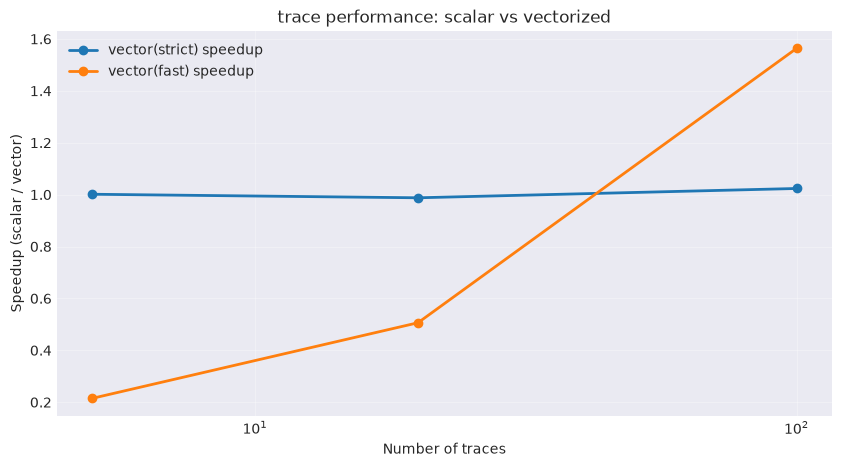

In [8]:
def bench_scalar(n_traces, starts, **trace_kw):
    t0 = time.time()
    endpoints = []
    for i in range(n_traces):
        xi, yi, zi = float(starts[0][i]), float(starts[1][i]), float(starts[2][i])
        xf, yf, zf, xx, yy, zz, st = trace_scalar_normalized(xi, yi, zi, **trace_kw)
        endpoints.append((xf, yf, zf, st, len(xx)))
    t1 = time.time()
    return (t1 - t0), endpoints

def bench_vectorized(n_traces, starts, strict, **trace_kw):
    t0 = time.time()
    xf, yf, zf, xx, yy, zz, status, nsteps = trace_vectorized_normalized(
        starts[0], starts[1], starts[2],
        strict_scalar_models=strict,
        return_full_path=False,  # No path for speed comparison
        return_nsteps=True,
        **trace_kw
    )
    t1 = time.time()
    return (t1 - t0), (xf, yf, zf, status, nsteps)

# Generate random initial points (outside r0)
rng = np.random.default_rng(0)
def random_starts(n):
    # X in -12..+5, Y,Z in -5..+5, ensuring r>1.2
    xs = rng.uniform(-12, 5, n)
    ys = rng.uniform(-5, 5, n)
    zs = rng.uniform(-5, 5, n)
    r = norm3(xs, ys, zs)
    ok = r > 1.2
    # Regenerate if not enough (simple approach)
    while np.sum(ok) < n:
        xs2 = rng.uniform(-12, 5, n)
        ys2 = rng.uniform(-5, 5, n)
        zs2 = rng.uniform(-5, 5, n)
        r2 = norm3(xs2, ys2, zs2)
        ok2 = r2 > 1.2
        xs = np.where(ok, xs, xs2)
        ys = np.where(ok, ys, ys2)
        zs = np.where(ok, zs, zs2)
        ok = norm3(xs, ys, zs) > 1.2
    return xs, ys, zs

sizes = [5, 20, 100]
rows = []

for n in sizes:
    xs, ys, zs = random_starts(n)

    # scalar
    t_s, _ = bench_scalar(
        n, (xs, ys, zs),
        dir=+1.0, rlim=TRACE_RLIM, r0=TRACE_R0,
        parmod=parmod, exname=exname, inname=inname, maxloop=TRACE_MAXLOOP,
    )

    # vector strict
    t_v_strict, _ = bench_vectorized(
        n, (xs, ys, zs),
        strict=True,
        dir=+1.0, rlim=TRACE_RLIM, r0=TRACE_R0,
        parmod=parmod, exname=exname, inname=inname, maxloop=TRACE_MAXLOOP,
    )

    # vector fast
    t_v_fast, _ = bench_vectorized(
        n, (xs, ys, zs),
        strict=False,
        dir=+1.0, rlim=TRACE_RLIM, r0=TRACE_R0,
        parmod=parmod, exname=exname, inname=inname, maxloop=TRACE_MAXLOOP,
    )

    rows.append(dict(
        n_traces=n,
        scalar_s=t_s,
        vec_strict_s=t_v_strict,
        vec_fast_s=t_v_fast,
        speedup_strict=(t_s / max(t_v_strict, 1e-12)),
        speedup_fast=(t_s / max(t_v_fast, 1e-12)),
    ))

df = pd.DataFrame(rows)
display(df)

plt.figure(figsize=(10, 5))
plt.plot(df["n_traces"], df["speedup_strict"], "o-", lw=2, label="vector(strict) speedup")
plt.plot(df["n_traces"], df["speedup_fast"], "o-", lw=2, label="vector(fast) speedup")
plt.xscale("log")
plt.xlabel("Number of traces")
plt.ylabel("Speedup (scalar / vector)")
plt.title("trace performance: scalar vs vectorized")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 9) Generic tracing with `mageometry.trace_field_lines`

The engine tracer above is tied to the geopack models (`exname`/`inname`/`parmod`). The library-level tracer takes a **field callable** instead, so the same call traces Tsyganenko fields and simulation data. Differences to keep in mind:

- `direction=+1` follows **B** (geopack's `dir=+1` is *anti*-parallel); `direction='both'` traces both senses and joins them into one path with the seed at `start_index`.
- Boundary crossings (`r0`, `rlim`, a bounding `bounds` box) are placed exactly on the boundary; `stop(x, y, z)` adds custom conditions; an undefined field (NaN outside a grid, magnetic null) terminates the line with status 3.
- The result is a `FieldLineTrace` with NaN-padded path arrays, `arc_length(i)`, `nsteps`, and `status` codes.

FieldLineTrace(n_lines=12, max_points=123, status={'inner': 8, 'outer': 4})
status (+B end): [1 1 1 1 0 0 0 0 0 0 0 0]
status (-B end): [0 0 0 0 0 0 0 1 1 1 1 1]


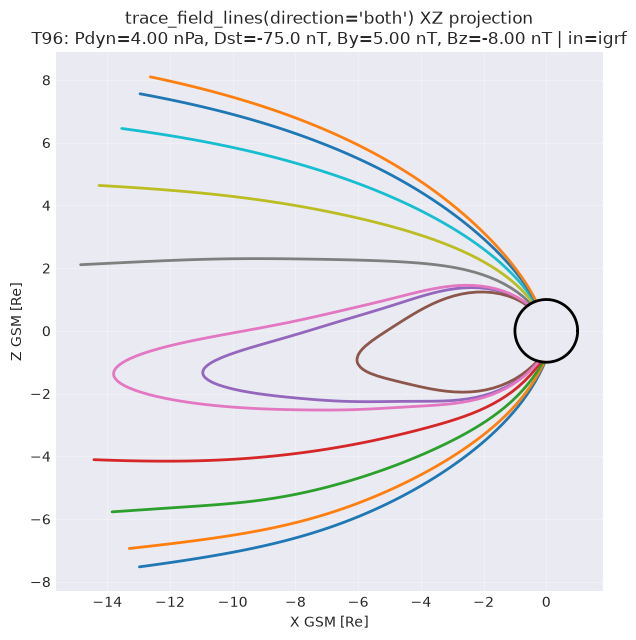

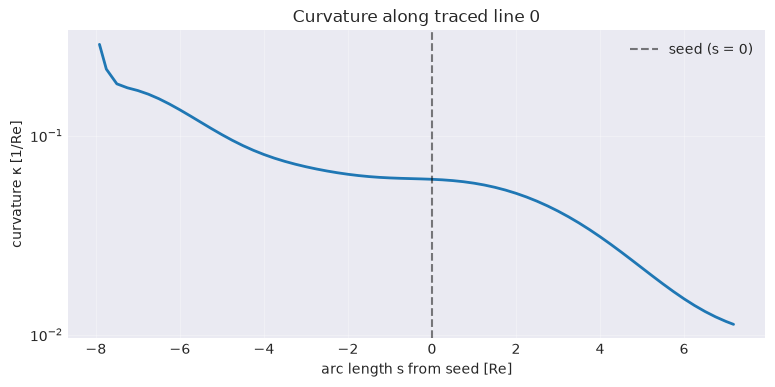

In [9]:
from mageometry import geopack_field, trace_field_lines, field_line_curvature

field = geopack_field(exname, inname, parmod, ps)   # same model and parameters as above

tr = trace_field_lines(field, xi_arr, yi_arr, zi_arr, direction="both", ds=0.25,
                       r0=TRACE_R0, rlim=TRACE_RLIM)
print(tr)
print("status (+B end):", tr.status)
print("status (-B end):", tr.status_backward)

plot_field_lines_xz(
    lines=[{"xx": tr.path(i)[0], "zz": tr.path(i)[2], "label": None, "style": "-"} for i in range(tr.n_lines)],
    title=f"trace_field_lines(direction='both') XZ projection\n{pretty_parmod(exname, parmod)} | in={inname}",
)

# Geometry along a traced line: curvature vs arc length
x, y, z = tr.path(0)
s = tr.arc_length(0)
kappa = field_line_curvature(field, x, y, z, delta=0.05)
plt.figure(figsize=(9, 4))
plt.semilogy(s, kappa, lw=2)
plt.axvline(0, color="k", ls="--", alpha=0.5, label="seed (s = 0)")
plt.xlabel("arc length s from seed [Re]"); plt.ylabel("curvature κ [1/Re]")
plt.title("Curvature along traced line 0"); plt.grid(True, alpha=0.3); plt.legend()
plt.show()